In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def find_weighted_2d_mode(df, x_col, y_col, weight_col, bins=100):
    """
    Finds the mode (peak) of a weighted 2D distribution.
    """
    H, xedges, yedges = np.histogram2d(
        x=df[x_col],
        y=df[y_col],
        bins=bins,
        weights=df[weight_col]
    )

    # --- THIS IS THE CORRECTED LINE ---
    # The default indexing='xy' for histogram2d means H has shape (nx, ny).
    # So the first index corresponds to x (D_L) and the second to y (D_S).
    ix, iy = np.unravel_index(np.argmax(H), H.shape)

    # Calculate the center of the peak bin to get the mode coordinates.
    mode_x = (xedges[ix] + xedges[ix+1]) / 2
    mode_y = (yedges[iy] + yedges[iy+1]) / 2

    return mode_x, mode_y

In [10]:
def weighted_median(data, weights):
    """
    Calculates the weighted median of a 1D array.

    Args:
        data (pd.Series or np.array): The data values.
        weights (pd.Series or np.array): The corresponding weights.

    Returns:
        float: The weighted median.
    """
    # Sort the data and weights together
    sorted_indices = np.argsort(data)
    data_sorted = data[sorted_indices]
    weights_sorted = weights[sorted_indices]

    # Calculate the cumulative sum of weights
    cumulative_weights = np.cumsum(weights_sorted)
    total_weight = cumulative_weights.iloc[-1]

    # Find the midpoint
    median_weight_point = total_weight / 2.0

    # Find the index where the cumulative weight exceeds the midpoint
    # The [0] is to get the first index that satisfies the condition
    median_index = np.where(cumulative_weights >= median_weight_point)[0][0]

    return data_sorted.iloc[median_index]

The most typical combination (2D Mode) is:
  Lens Distance (D_L): 1.25 kpc
  Source Distance (D_S): 7.91 kpc
Weighted Medians:
  Median Lens Distance (D_L): 1.16 kpc
  Median Source Distance (D_S): 7.97 kpc


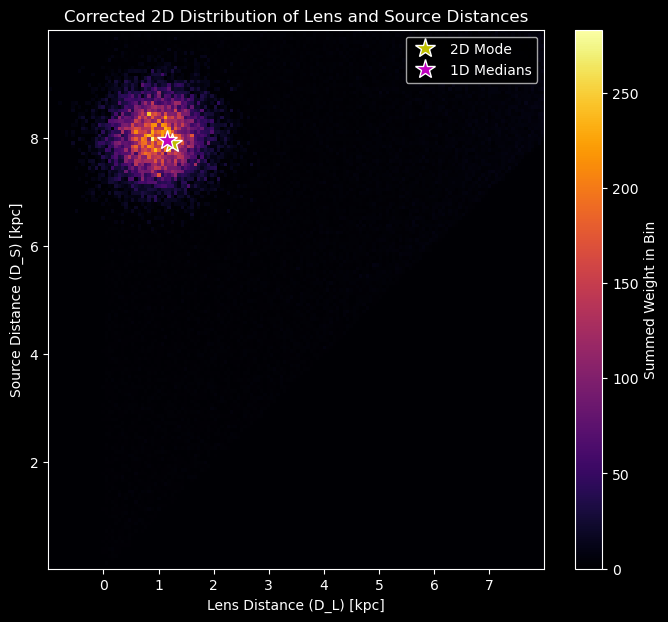

In [18]:
# 1. Create the sample DataFrame
np.random.seed(42)
n_samples = 50000
dl_bg = np.random.uniform(0, 8, n_samples)
ds_bg = np.random.uniform(dl_bg, 10, n_samples)
weights_bg = np.random.uniform(0.1, 1, n_samples)
dl_peak = np.random.normal(loc=1.0, scale=0.5, size=int(n_samples/5))
ds_peak = np.random.normal(loc=8.0, scale=0.5, size=int(n_samples/5))
weights_peak = np.random.uniform(5, 10, int(n_samples/5))
df_sample = pd.DataFrame({
    'D_L': np.concatenate([dl_bg, dl_peak]),
    'D_S': np.concatenate([ds_bg, ds_peak]),
    'weight': np.concatenate([weights_bg, weights_peak])
})

# 2. Find the 2D mode using the corrected function.
dl_mode, ds_mode = find_weighted_2d_mode(
    df=df_sample,
    x_col='D_L',
    y_col='D_S',
    weight_col='weight',
    bins=150
)

print(f"The most typical combination (2D Mode) is:")
print(f"  Lens Distance (D_L): {dl_mode:.2f} kpc")
print(f"  Source Distance (D_S): {ds_mode:.2f} kpc")


# 3. Calculate the weighted median for D_L and D_S
median_dl = weighted_median(data=df_sample['D_L'], weights=df_sample['weight'])
median_ds = weighted_median(data=df_sample['D_S'], weights=df_sample['weight'])

print("Weighted Medians:")
print(f"  Median Lens Distance (D_L): {median_dl:.2f} kpc")
print(f"  Median Source Distance (D_S): {median_ds:.2f} kpc")


# 4. Visualize the result.
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 7))
hist = ax.hist2d(
    df_sample['D_L'],
    df_sample['D_S'],
    bins=150,
    weights=df_sample['weight'],
    cmap='inferno'
)
fig.colorbar(hist[3], ax=ax, label='Summed Weight in Bin')
ax.plot(dl_mode, ds_mode, 'y*', markersize=15, markeredgecolor='white', label='2D Mode')
ax.plot(median_dl, median_ds, 'm*', markersize=15, markeredgecolor='white', label='1D Medians')
ax.set_title('Corrected 2D Distribution of Lens and Source Distances')
ax.set_xlabel('Lens Distance (D_L) [kpc]')
ax.set_ylabel('Source Distance (D_S) [kpc]')
ax.legend()
plt.show()

The most typical combination (2D Mode) is:
  Lens Distance (D_L): 7.99 kpc
  Source Distance (D_S): 8.78 kpc
Weighted Medians:
  Median Lens Distance (D_L): 7.59 kpc
  Median Source Distance (D_S): 8.55 kpc


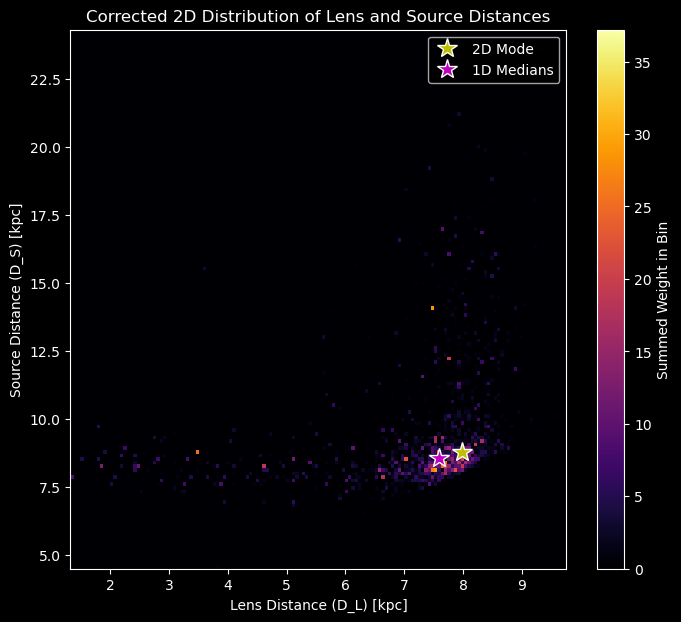

In [19]:

# --- Calculate using a Gulls Representative sample ---

# 1. Column Mapping
# D_L = Lens_Dist
# D_S = Source_Dist
# weight = weight

# 2. Load the data
path = "repsample/OMPLLD_croin_cassan_0.sample.csv"
# first row is the header
header = pd.read_csv(path, nrows=1).columns.tolist()

# load the data
data = pd.read_csv(path, skiprows=1)

# rename the columns
data.columns = header

# make a new df with the correct columns and rename them
df_sample = data[["Lens_Dist", "Source_Dist", "weight"]]
df_sample.columns = ["D_L", "D_S", "weight"]


# 3. Find the 2D mode using the corrected function.
dl_mode, ds_mode = find_weighted_2d_mode(
    df=df_sample,
    x_col='D_L',
    y_col='D_S',
    weight_col='weight',
    bins=150
)

print(f"The most typical combination (2D Mode) is:")
print(f"  Lens Distance (D_L): {dl_mode:.2f} kpc")
print(f"  Source Distance (D_S): {ds_mode:.2f} kpc")


# 4. Calculate the weighted median for D_L and D_S
median_dl = weighted_median(data=df_sample['D_L'], weights=df_sample['weight'])
median_ds = weighted_median(data=df_sample['D_S'], weights=df_sample['weight'])

print("Weighted Medians:")
print(f"  Median Lens Distance (D_L): {median_dl:.2f} kpc")
print(f"  Median Source Distance (D_S): {median_ds:.2f} kpc")


# 5. Visualize the result.
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 7))
hist = ax.hist2d(
    df_sample['D_L'],
    df_sample['D_S'],
    bins=150,
    weights=df_sample['weight'],
    cmap='inferno'
)
fig.colorbar(hist[3], ax=ax, label='Summed Weight in Bin')
ax.plot(dl_mode, ds_mode, 'y*', markersize=15, markeredgecolor='white', label='2D Mode')
ax.plot(median_dl, median_ds, 'm*', markersize=15, markeredgecolor='white', label='1D Medians')
ax.set_title('Corrected 2D Distribution of Lens and Source Distances')
ax.set_xlabel('Lens Distance (D_L) [kpc]')
ax.set_ylabel('Source Distance (D_S) [kpc]')
ax.legend()
plt.show()